## RAG Evaluation with DeepEval 3.6.7
## This notebook evaluates the Odoo AI Tutor RAG system using DeepEval metrics


### %% Install dependencies (run once)

In [32]:
%pip install deepeval==3.6.7 requests matplotlib pandas torch chromadb sentence-transformers

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.0 MB 6.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/12.0 MB 7.0 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.0 MB 7.0 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.0 MB 7.0 MB/s eta 0:00:01
   ------------------- -------------------- 5.8/12.0 MB 5.4 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.0 MB 5.7 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.0 MB 5.6 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.0 MB 5.3 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.0 MB 5.0 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.0 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 5.0 MB/s  0:00:02
   ---------------------------------------- 0.0/566.1 kB ? eta -:--:--
   ----------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [ ]:
import json
import logging
import os
from typing import List

import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
import chromadb
from deepeval.metrics import (
    AnswerRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric,
    FaithfulnessMetric,
)
from deepeval.test_case import LLMTestCase
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer, util

# Load environment variables
load_dotenv()

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# %% Configuration
# API_BASE_URL = os.getenv("API_BASE_URL", "http://localhost:8001")
API_KEY = os.getenv("API_KEY", "x-api-key")
API_BASE_URL = os.getenv("API_BASE_URL", "https://tutor-backend.odooconcept.com/")


# Initialize embedding model for retrieval context
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# ChromaDB configuration (to get actual retrieval context)
CHROMA_HOST = os.getenv("CHROMA_HOST", "localhost")
CHROMA_PORT = int(os.getenv("CHROMA_PORT", "8500"))
CHROMA_API_KEY = os.getenv("CHROMA_API_KEY", "")


def get_chroma_client():
    """Get ChromaDB client"""
    return chromadb.HttpClient(
        host=CHROMA_HOST,
        port=CHROMA_PORT,
        headers={"x-chroma-token": CHROMA_API_KEY},
        tenant=os.getenv("CHROMA_TENANT", "default_tenant"),
        database=os.getenv("CHROMA_DATABASE", "default_database"),
        ssl=True,
    )

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: paraphrase-multilingual-MiniLM-L12-v2


In [122]:
# %% Disable Confident AI completely
import os
from deepeval.test_run import global_test_run_manager

os.environ["DEEPEVAL_TELEMETRY_OPT_OUT"] = "YES"

# Run this in a separate cell BEFORE any other code
global_test_run_manager.disable_request = True

In [123]:
def call_chat_endpoint(message: str, model: str = "sale.order") -> dict:
    """
    Call the /chat endpoint and return the response
    """
    url = f"{API_BASE_URL}/chat"
    headers = {"x-api-key": API_KEY, "Content-Type": "application/json"}
    payload = {"message": message, "context": {"model": model}}

    try:
        response = requests.post(url, json=payload, headers=headers)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        logger.error(f"Error calling chat endpoint: {e}")
        raise

In [124]:
# %% Helper function to get retrieval context from ChromaDB
def get_retrieval_context(message: str) -> List[str]:
    """
    Get the actual context retrieved from ChromaDB for a given query.
    """
    try:
        # Don't import - use chromadb directly
        client = get_chroma_client()
        collection = client.get_collection(name="exercises")

        # Get all documents and embeddings
        results = collection.get(include=["metadatas", "documents", "embeddings"])

        if not results["ids"]:
            logger.warning("No exercises found in ChromaDB")
            return ["No exercises found in database"]

        # Encode user message
        user_embedding = embedding_model.encode(
            message.lower(), convert_to_tensor=True, convert_to_numpy=False
        ).to(dtype=torch.float32)

        # Convert exercise embeddings to tensor
        exercise_embeddings = torch.tensor(results["embeddings"], dtype=torch.float32)

        # Compute cosine similarity
        similarities = util.cos_sim(user_embedding, exercise_embeddings)[0]
        best_idx = int(similarities.argmax())
        best_score = float(similarities[best_idx])

        logger.info(f"Best similarity score for '{message}': {best_score:.4f}")

        # If similarity is above threshold (0.5)
        if best_score > 0.5:
            exercise_data = results["metadatas"][best_idx]

            # Build retrieval context from actual exercise data
            retrieval_context = []

            # Add goal
            if "goal" in exercise_data:
                retrieval_context.append(exercise_data["goal"])

            # Add instructions
            if "instructions" in exercise_data:
                instructions = json.loads(exercise_data["instructions"])
                retrieval_context.extend(instructions)

            # Add hints
            if "hints" in exercise_data:
                hints = json.loads(exercise_data.get("hints", "[]"))
                if hints:
                    retrieval_context.extend(hints)

            logger.info(f"Retrieved {len(retrieval_context)} context items")
            return retrieval_context
        else:
            logger.warning(f"Low similarity score: {best_score:.4f}")
            return ["No matching exercise found"]

    except Exception as e:
        logger.error(f"Error getting retrieval context: {e}", exc_info=True)
        return ["No relevant context available"]

### Define Golden Test Cases
#### These represent ideal question-answer pairs with expected context


In [125]:
golden_test_cases = [
    {
        "input": "How to register a payment for a customer invoice?",
        "expected_output": "To register a payment for a customer invoice in Odoo, navigate to the Accounting or Invoicing module, locate the customer invoice you want to pay, click on 'Register Payment', enter the payment amount and date, select the payment method (bank, cash, etc.), and confirm the payment. The invoice status will update to 'Paid'.",
        "expected_context": [
            "Go to Accounting/Invoicing module",
            "Open the customer invoice",
            "Click 'Register Payment' button",
            "Enter payment details: amount, date, payment method",
            "Select payment journal (Bank, Cash, etc.)",
            "Confirm the payment",
            "Invoice status changes to 'Paid'",
        ],
        "model": "account.move",
    },
    {
        "input": "How to configure a replenishment rule for a manufactured product in the Inventory app?",
        "expected_output": "To configure a replenishment rule for a manufactured product in Odoo Inventory, go to the Inventory module, navigate to Configuration > Reordering Rules, click 'Create', select the manufactured product, set the minimum and maximum quantities, choose 'Manufacture' as the route, define the location, and save the rule. This will automatically trigger manufacturing orders when stock falls below the minimum quantity.",
        "expected_context": [
            "Open Inventory module",
            "Go to Configuration > Reordering Rules",
            "Click 'Create' to add new rule",
            "Select the product to replenish",
            "Set minimum quantity (reorder point)",
            "Set maximum quantity (target stock level)",
            "Choose route: 'Manufacture' for manufactured products",
            "Define warehouse location",
            "Save the reordering rule",
            "System will auto-generate manufacturing orders when needed",
        ],
        "model": "stock.warehouse.orderpoint",
    },
]

### Create DeepEval Test Cases

In [126]:
def create_test_cases() -> List[LLMTestCase]:
    """
    Create DeepEval test cases by calling the actual RAG endpoint
    """
    test_cases = []

    for golden in golden_test_cases:
        logger.info(f"Processing: {golden['input']}")

        # Get actual response from RAG system
        rag_response = call_chat_endpoint(golden["input"], golden["model"])
        actual_output = rag_response.get("response", "")

        # Get retrieval context
        retrieval_context = get_retrieval_context(golden["input"])

        # Create test case
        test_case = LLMTestCase(
            input=golden["input"],
            actual_output=actual_output,
            expected_output=golden["expected_output"],
            retrieval_context=retrieval_context,
            context=golden["expected_context"],  # Expected/golden context
        )

        test_cases.append(test_case)
        logger.info(f"Created test case with actual output: {actual_output[:100]}...")

    return test_cases

#### Initialize Metrics

In [127]:
# %% Initialize Metrics (with telemetry disabled)
def initialize_metrics():
    """
    Initialize all DeepEval metrics with telemetry disabled
    """
    # Check if OpenAI API key is set
    if not os.getenv("OPENAI_API_KEY"):
        raise ValueError(
            "OPENAI_API_KEY not found in environment variables. Please set it in your .env file"
        )

    # Choose your model (gpt-4, gpt-3.5-turbo, gpt-4-turbo)
    evaluation_model = "gpt-3.5-turbo"  # Change this if needed

    return [
        AnswerRelevancyMetric(
            threshold=0.2,
            model=evaluation_model,
            async_mode=False,  # Disable async to avoid telemetry issues
        ),
        FaithfulnessMetric(threshold=0.2, model=evaluation_model, async_mode=False),
        ContextualPrecisionMetric(
            threshold=0.2, model=evaluation_model, async_mode=False
        ),
        ContextualRecallMetric(threshold=0.2, model=evaluation_model, async_mode=False),
        ContextualRelevancyMetric(
            threshold=0.2, model=evaluation_model, async_mode=False
        ),
    ]

### Run Evaluation

In [128]:
# %% Run Evaluation (fixed version)
from datetime import datetime


def run_evaluation():
    """
    Run the complete evaluation pipeline WITHOUT using evaluate()
    """
    logger.info("Creating test cases...")
    test_cases = create_test_cases()

    logger.info("Initializing metrics...")

    formatted_results = {
        "test_cases": [],
        "summary": {
            "total_test_cases": len(test_cases),
            "total_metrics": 5,
            "timestamp": datetime.now().isoformat(),
        },
    }

    try:
        print(f"\n📊 Evaluating {len(test_cases)} test cases with 5 metrics...")

        # Evaluate each test case individually to capture metrics properly
        for i, test_case in enumerate(test_cases):
            print(f"\n🔄 Evaluating test case {i+1}/{len(test_cases)}...")

            test_case_result = {
                "test_case_id": i + 1,
                "input": test_case.input,
                "actual_output": test_case.actual_output,
                "expected_output": getattr(test_case, "expected_output", ""),
                "retrieval_context": getattr(test_case, "retrieval_context", []),
                "context": getattr(test_case, "context", []),
                "metrics": [],
            }

            # Create fresh metrics for each test case
            metrics = initialize_metrics()

            # Evaluate each metric individually for this test case
            for metric in metrics:
                metric_name = metric.__class__.__name__.replace("Metric", "")

                try:
                    # Measure the metric for this test case
                    metric.measure(test_case)

                    metric_result = {
                        "metric": metric_name,
                        "score": metric.score if hasattr(metric, "score") else None,
                        "success": (
                            metric.success if hasattr(metric, "success") else None
                        ),
                        "threshold": (
                            metric.threshold if hasattr(metric, "threshold") else 0.0
                        ),
                        "reason": metric.reason if hasattr(metric, "reason") else "",
                    }

                    test_case_result["metrics"].append(metric_result)

                    # Print metric result
                    score_str = (
                        f"{metric_result['score']:.4f}"
                        if metric_result["score"] is not None
                        else "N/A"
                    )
                    success_str = "✅" if metric_result["success"] else "❌"
                    print(f"  {success_str} {metric_name}: {score_str}")

                except Exception as metric_error:
                    print(
                        f"  ⚠️ Warning: Error evaluating {metric_name}: {metric_error}"
                    )
                    test_case_result["metrics"].append(
                        {
                            "metric": metric_name,
                            "score": None,
                            "success": None,
                            "threshold": 0.0,
                            "reason": f"Error: {str(metric_error)}",
                        }
                    )

            formatted_results["test_cases"].append(test_case_result)

        print("\n✅ Evaluation completed successfully!")

    except Exception as e:
        print(f"❌ Error during evaluation: {str(e)}")
        import traceback

        traceback.print_exc()

    print(
        f"\n📦 Returning results with {len(formatted_results['test_cases'])} test cases"
    )
    return formatted_results, test_cases

#### Extract and Display Results

In [129]:
# %% Extract and Display Results (updated to use formatted_results)
def display_results(formatted_results: dict):
    """
    Extract metric scores and display results from formatted_results
    """
    metric_names = [
        "AnswerRelevancy",
        "Faithfulness",
        "ContextualPrecision",
        "ContextualRecall",
        "ContextualRelevancy",
    ]

    # Collect scores for each metric across all test cases
    scores = {metric: [] for metric in metric_names}

    for test_case_result in formatted_results["test_cases"]:
        for metric_result in test_case_result["metrics"]:
            metric_name = metric_result["metric"]
            if metric_name in scores and metric_result["score"] is not None:
                scores[metric_name].append(metric_result["score"])

    # Calculate averages
    averages = {}
    for metric in metric_names:
        if scores[metric]:
            averages[metric] = sum(scores[metric]) / len(scores[metric])
        else:
            averages[metric] = 0.0

    # Display text results
    print("\n" + "=" * 50)
    print("📈 Overall Metric Average Scores:")
    print("=" * 50)
    for metric, avg_score in averages.items():
        print(f"{metric}: {avg_score:.4f}")
    print("=" * 50 + "\n")

    return averages

### Visualize Results

In [130]:
def plot_results(averages: dict):
    """
    Create bar chart visualization of metric scores
    """
    metrics = list(averages.keys())
    scores = list(averages.values())

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # Create bars
    bars = ax.bar(
        metrics, scores, color=["#3498db", "#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"]
    )

    # Customize chart
    ax.set_ylabel("Score", fontsize=12, fontweight="bold")
    ax.set_xlabel("Metrics", fontsize=12, fontweight="bold")
    ax.set_title(
        "RAG Evaluation Metrics - Average Scores",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    ax.set_ylim(0, 1.1)
    ax.axhline(
        y=0.7,
        color="red",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label="Threshold (0.7)",
    )

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )

    # Add grid
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend()

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return fig

### Create detailed DataFrame

In [131]:
# %% Create detailed DataFrame (updated)
def create_detailed_dataframe(formatted_results: dict) -> pd.DataFrame:
    """
    Create a detailed DataFrame with all test cases and their scores
    """
    metric_names = [
        "AnswerRelevancy",
        "Faithfulness",
        "ContextualPrecision",
        "ContextualRecall",
        "ContextualRelevancy",
    ]

    data = []

    for test_case_result in formatted_results["test_cases"]:
        row = {
            "Test Case": test_case_result["test_case_id"],
            "Input": (
                test_case_result["input"][:60] + "..."
                if len(test_case_result["input"]) > 60
                else test_case_result["input"]
            ),
        }

        # Get scores from metrics
        for metric_result in test_case_result["metrics"]:
            metric_name = metric_result["metric"]
            if metric_name in metric_names:
                score = metric_result["score"]
                row[metric_name] = f"{score:.4f}" if score is not None else "N/A"

        data.append(row)

    df = pd.DataFrame(data)
    return df

### Main Execution

INFO:__main__:Creating test cases...
INFO:__main__:Processing: How to register a payment for a customer invoice?


Starting RAG Evaluation with DeepEval...
API Base URL: https://tutor-backend.odooconcept.com/



INFO:chromadb.telemetry.product.posthog:Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
INFO:httpx:HTTP Request: GET https://api.trychroma.com/api/v2/auth/identity "HTTP/1.1 200 OK"
INFO:chromadb.telemetry.product.posthog:Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
INFO:httpx:HTTP Request: GET https://api.trychroma.com/api/v2/tenants/f9af1745-ad3f-4913-ad79-11562e801337 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.trychroma.com/api/v2/tenants/f9af1745-ad3f-4913-ad79-11562e801337/databases/odoo_tutor "HTTP/1.1 200 OK"
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
INFO:httpx:HTTP Request: GET https://api.trychroma.com/api/v2/tenants/f9af1745-ad3f-4913-ad79-11562e801337/databases/odoo_tutor/collections/exercises "HTTP/1.1 200 OK"
INFO:httpx:HTTP 


📊 Evaluating 2 test cases with 5 metrics...

🔄 Evaluating test case 1/2...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

  ✅ ContextualPrecision: 0.8393


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  ✅ ContextualRecall: 1.0000


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"

  ❌ ContextualRelevancy: 0.0714

✅ Evaluation completed successfully!

📦 Returning results with 2 test cases

📈 Overall Metric Average Scores:
AnswerRelevancy: 0.7500
Faithfulness: 0.5000
ContextualPrecision: 0.8363
ContextualRecall: 0.7500
ContextualRelevancy: 0.2175



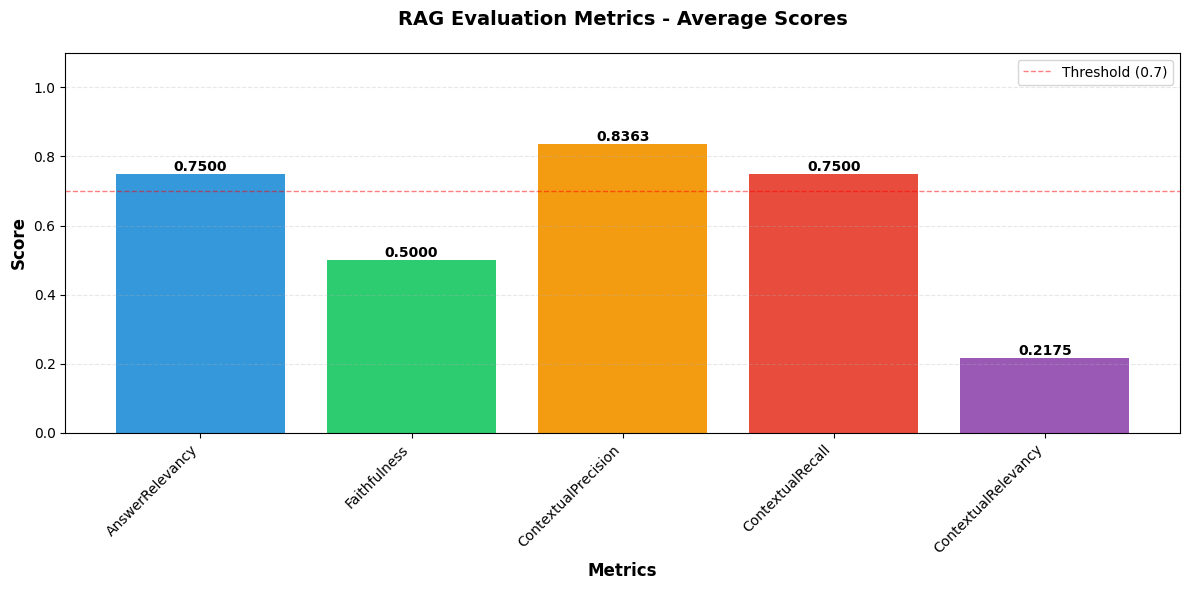


📊 Detailed Results by Test Case:
 Test Case                                                           Input AnswerRelevancy Faithfulness ContextualPrecision ContextualRecall ContextualRelevancy
         1               How to register a payment for a customer invoice?          1.0000       1.0000              0.8333           0.5000              0.3636
         2 How to configure a replenishment rule for a manufactured pro...          0.5000       0.0000              0.8393           1.0000              0.0714

✅ Done!


In [135]:
# %% Main Execution (with better error suppression)
if __name__ == "__main__":
    from datetime import datetime
    import warnings
    import logging

    # Suppress all warnings
    warnings.filterwarnings("ignore")

    # Suppress asyncio errors
    logging.getLogger("asyncio").setLevel(logging.CRITICAL)

    # Suppress DeepEval telemetry logging
    logging.getLogger("deepeval").setLevel(logging.CRITICAL)

    print("Starting RAG Evaluation with DeepEval...")
    print(f"API Base URL: {API_BASE_URL}\n")

    # Run evaluation
    formatted_results, test_cases = run_evaluation()

    # Display results
    averages = display_results(formatted_results)

    # Create visualizations
    fig = plot_results(averages)

    # Create detailed results table
    df_results = create_detailed_dataframe(formatted_results)
    print("\n📊 Detailed Results by Test Case:")
    print(df_results.to_string(index=False))

    print("\n✅ Done!")